In [1]:
!pip install opencv-contrib-python scikit-learn tqdm -q

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os, cv2, glob, random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

DATASET_PATH = "/content/drive/MyDrive/dataset_dl_lab/coco128"
IMG_DIR = DATASET_PATH + "/images/train2017"
LBL_DIR = DATASET_PATH + "/labels/train2017"

images_list = sorted(glob.glob(IMG_DIR + "/*.jpg"))

print("Total images:", len(images_list))
print(images_list[:3])

Total images: 128
['/content/drive/MyDrive/dataset_dl_lab/coco128/images/train2017/000000000009.jpg', '/content/drive/MyDrive/dataset_dl_lab/coco128/images/train2017/000000000025.jpg', '/content/drive/MyDrive/dataset_dl_lab/coco128/images/train2017/000000000030.jpg']


In [26]:
def yolo_to_xyxy(label_path, img_w, img_h):
    boxes = []
    classes = []

    if not os.path.exists(label_path):
        return boxes, classes

    with open(label_path, "r") as f:
        for line in f.readlines():
            data = line.strip().split()

            cls = int(data[0])
            x, y, w, h = map(float, data[1:])

            x1 = int((x - w / 2) * img_w)
            y1 = int((y - h / 2) * img_h)
            x2 = int((x + w / 2) * img_w)
            y2 = int((y + h / 2) * img_h)

            boxes.append([x1, y1, x2, y2])
            classes.append(cls)

    return boxes, classes

In [27]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    areaB = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])

    union = areaA + areaB - inter

    if union == 0:
        return 0

    return inter / union

In [28]:
def selective_search(img, max_regions=500):
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(img)
    ss.switchToSelectiveSearchFast()

    rects = ss.process()

    proposals = []
    h, w = img.shape[:2]

    for x, y, rw, rh in rects[:max_regions]:
        if rw < 20 or rh < 20:
            continue

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(w, x + rw)
        y2 = min(h, y + rh)

        proposals.append([x1, y1, x2, y2])

    return proposals

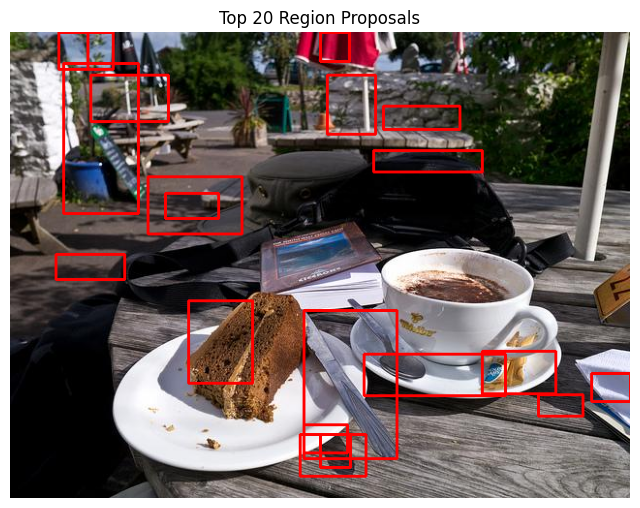

In [30]:
img_path = images_list[23]

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

proposals = selective_search(img, max_regions=500)

vis = img_rgb.copy()

for box in proposals[:20]:
    x1, y1, x2, y2 = box
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(vis)
plt.axis("off")
plt.title("Top 20 Region Proposals")
plt.show()

In [31]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

cnn_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

print("ResNet50 loaded successfully")

ResNet50 loaded successfully


In [32]:
cnn_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [33]:
def extract_feature(img, box):
    x1, y1, x2, y2 = box

    crop = img[y1:y2, x1:x2]

    if crop.size == 0:
        return None

    crop = cv2.resize(crop, (224, 224))
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop = img_to_array(crop)
    crop = np.expand_dims(crop, axis=0)
    crop = preprocess_input(crop)

    feature = cnn_model.predict(crop, verbose=0)

    return feature.flatten()

In [35]:
NUM_IMAGES = 50
MAX_PROPOSALS = 500

SELECTED_CLASSES = [0, 1, 2, 3, 5, 7, 9, 11, 15, 16, 17]

X_features = []
y_labels = []
reg_targets = []

selected_images = images_list[:NUM_IMAGES]

for img_path in tqdm(selected_images):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    label_path = img_path.replace(IMG_DIR, LBL_DIR).replace(".jpg", ".txt")

    gt_boxes, gt_classes = yolo_to_xyxy(label_path, w, h)

    filtered = []

    for box, cls in zip(gt_boxes, gt_classes):
        if cls in SELECTED_CLASSES:
            filtered.append((box, cls))

    if len(filtered) == 0:
        continue

    gt_boxes, gt_classes = zip(*filtered)
    gt_boxes = list(gt_boxes)
    gt_classes = list(gt_classes)

    proposals = selective_search(img, max_regions=MAX_PROPOSALS)

    # Important fix: add ground truth boxes as positive samples
    proposals = proposals + gt_boxes

    for prop in proposals:
        best_iou = 0
        best_gt = None
        best_cls = -1

        for gt_box, gt_cls in zip(gt_boxes, gt_classes):
            iou = compute_iou(prop, gt_box)

            if iou > best_iou:
                best_iou = iou
                best_gt = gt_box
                best_cls = gt_cls

        feat = extract_feature(img, prop)

        if feat is None:
            continue

        # positive sample
        if best_iou >= 0.3:
            X_features.append(feat)
            y_labels.append(best_cls)

            px1, py1, px2, py2 = prop
            gx1, gy1, gx2, gy2 = best_gt

            reg_targets.append([
                gx1 - px1,
                gy1 - py1,
                gx2 - px2,
                gy2 - py2
            ])

        # background sample
        elif best_iou < 0.2:
            X_features.append(feat)
            y_labels.append(-1)
            reg_targets.append([0, 0, 0, 0])

100%|██████████| 50/50 [14:56<00:00, 17.93s/it]


In [36]:
X_features = np.array(X_features)
y_labels = np.array(y_labels)
reg_targets = np.array(reg_targets)

print("Feature shape:", X_features.shape)
print("Labels shape:", y_labels.shape)
print("Regression targets:", reg_targets.shape)

print("Class distribution:")
print(np.unique(y_labels, return_counts=True))

Feature shape: (8096, 2048)
Labels shape: (8096,)
Regression targets: (8096, 4)
Class distribution:
(array([-1,  0,  1,  2,  3,  5,  7,  9, 11, 16, 17]), array([7604,  321,   11,   37,   14,   10,   40,   11,    9,   28,   11]))


In [37]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [38]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample
import numpy as np

# limit samples for faster training
MAX_BG = 800      # background samples
MAX_POS = 400     # positive samples per class

X_balanced = []
y_balanced = []

for cls in np.unique(y_labels):
    idx = np.where(y_labels == cls)[0]

    if cls == -1:
        idx_sampled = resample(
            idx,
            replace=False,
            n_samples=min(MAX_BG, len(idx)),
            random_state=42
        )
    else:
        idx_sampled = resample(
            idx,
            replace=False,
            n_samples=min(MAX_POS, len(idx)),
            random_state=42
        )

    X_balanced.append(X_features[idx_sampled])
    y_balanced.append(y_labels[idx_sampled])

X_train_svm = np.vstack(X_balanced)
y_train_svm = np.hstack(y_balanced)

print("Balanced training shape:", X_train_svm.shape)
print("Balanced labels:", np.unique(y_train_svm, return_counts=True))

svm_clf = make_pipeline(
    StandardScaler(),
    LinearSVC(
        max_iter=2000,
        class_weight="balanced",
        dual="auto",
        C=0.1
    )
)

svm_clf.fit(X_train_svm, y_train_svm)

print("Fast SVM trained successfully")

Balanced training shape: (1292, 2048)
Balanced labels: (array([-1,  0,  1,  2,  3,  5,  7,  9, 11, 16, 17]), array([800, 321,  11,  37,  14,  10,  40,  11,   9,  28,  11]))
Fast SVM trained successfully


In [39]:
from sklearn.linear_model import Ridge

positive_idx = np.where(y_labels != -1)[0]

# limit positive samples for faster regression
positive_idx = positive_idx[:1000]

bbox_regressor = Ridge(alpha=1.0)

bbox_regressor.fit(
    X_features[positive_idx],
    reg_targets[positive_idx]
)

print("Bounding box regressor trained successfully")

Bounding box regressor trained successfully


In [40]:
def nms(boxes, scores, iou_threshold=0.3):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    scores = np.array(scores)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)

        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]

    return keep

In [41]:
test_img_path = images_list[60]

test_img = cv2.imread(test_img_path)
test_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

proposals = selective_search(test_img, max_regions=500)

boxes = []
boxes_without_reg = []
scores = []
classes = []

for prop in tqdm(proposals):
    feat = extract_feature(test_img, prop)

    if feat is None:
        continue

    pred_class = svm_clf.predict([feat])[0]

    if pred_class == -1:
        continue

    decision = svm_clf.decision_function([feat])

    if len(decision.shape) == 1:
        score = np.max(decision)
    else:
        score = np.max(decision[0])

    delta = bbox_regressor.predict([feat])[0]

    x1, y1, x2, y2 = prop

    refined_box = [
        int(x1 + delta[0]),
        int(y1 + delta[1]),
        int(x2 + delta[2]),
        int(y2 + delta[3])
    ]

    boxes_without_reg.append(prop)
    boxes.append(refined_box)
    scores.append(score)
    classes.append(pred_class)

100%|██████████| 318/318 [00:30<00:00, 10.50it/s]


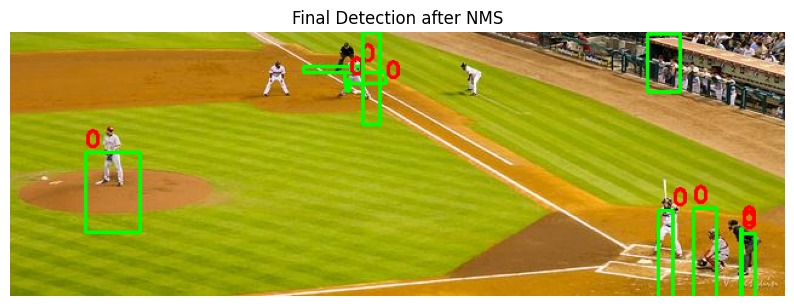

In [42]:
keep = nms(boxes, scores, iou_threshold=0.3)

result = test_rgb.copy()

for i in keep[:10]:
    x1, y1, x2, y2 = boxes[i]
    cls = classes[i]

    cv2.rectangle(result, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        result,
        str(cls),
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(10, 10))
plt.imshow(result)
plt.axis("off")
plt.title("Final Detection after NMS")
plt.show()

In [43]:
label_path = test_img_path.replace(IMG_DIR, LBL_DIR).replace(".jpg", ".txt")

h, w = test_img.shape[:2]

gt_boxes, gt_classes = yolo_to_xyxy(label_path, w, h)

filtered = []

for box, cls in zip(gt_boxes, gt_classes):
    if cls in SELECTED_CLASSES:
        filtered.append((box, cls))

if len(filtered) > 0:
    gt_boxes, gt_classes = zip(*filtered)
    gt_boxes = list(gt_boxes)
else:
    gt_boxes = []

final_boxes = [boxes[i] for i in keep]

ious = []

for pred_box in final_boxes:
    best_iou = 0

    for gt_box in gt_boxes:
        best_iou = max(best_iou, compute_iou(pred_box, gt_box))

    ious.append(best_iou)

print("Mean IoU:", np.mean(ious) if len(ious) > 0 else 0)

Mean IoU: 0.04452341800125364


In [44]:
def calculate_map(pred_boxes, gt_boxes, threshold=0.5):
    tp = 0
    fp = 0
    matched = set()

    for pred in pred_boxes:
        found_match = False

        for idx, gt in enumerate(gt_boxes):
            if idx in matched:
                continue

            if compute_iou(pred, gt) >= threshold:
                tp += 1
                matched.add(idx)
                found_match = True
                break

        if not found_match:
            fp += 1

    fn = len(gt_boxes) - len(matched)

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)

    ap = precision * recall

    return ap, precision, recall

In [45]:
boxes_without_reg_nms = [boxes_without_reg[i] for i in keep]
boxes_with_reg_nms = [boxes[i] for i in keep]

ap_without, p_without, r_without = calculate_map(
    boxes_without_reg_nms,
    gt_boxes
)

ap_with, p_with, r_with = calculate_map(
    boxes_with_reg_nms,
    gt_boxes
)

print("Without Bounding Box Regression")
print("AP:", ap_without)
print("Precision:", p_without)
print("Recall:", r_without)

print("\nWith Bounding Box Regression")
print("AP:", ap_with)
print("Precision:", p_with)
print("Recall:", r_with)

Without Bounding Box Regression
AP: 0.02564102313445123
Precision: 0.08333333159722227
Recall: 0.3076922840236705

With Bounding Box Regression
AP: 0.0
Precision: 0.0
Recall: 0.0
